# Linear Regression Handson

<https://colab.research.google.com/drive/1m_X-lUfSpnDXdylsi5afvl-CPZbxZsK5?usp=sharing#scrollTo=_-2WTlKlx_4Q>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl

In [16]:
# LOAD & OVERVIEW 

dataset = pd.read_csv('car_price_dataset.csv')
df = dataset.copy()

print('shape __________________________')
print(df.shape) 

print('data type ______________________')
print(df.dtypes)

print('head ___________________________')
print(df.head())

print('null ___________________________')
print(df.isnull().sum())

print('dup ____________________________')
print(df.duplicated().sum())

print('info ___________________________')
df.info()

shape __________________________
(10000, 10)
data type ______________________
Brand               str
ModelYear         int64
EngineSize        int64
Horsepower      float64
Mileage         float64
FuelType            str
Transmission        str
Seats             int64
OwnerCount        int64
Price           float64
dtype: object
head ___________________________
   Brand  ModelYear  EngineSize  ...  Seats  OwnerCount         Price
0    BMW       2013        2826  ...      7           1  50782.940822
1  Honda       2020        3870  ...      4           1  72925.496453
2   Audi       2000        1888  ...      4           0  65363.751108
3   Audi       2020        1181  ...      4           0  57857.039557
4   Audi       2017        1988  ...      5           1  61863.461952

[5 rows x 10 columns]
null ___________________________
Brand             0
ModelYear         0
EngineSize        0
Horsepower      500
Mileage         500
FuelType        500
Transmission      0
Seats             0

In [17]:
df

,Brand,ModelYear,EngineSize,Horsepower,Mileage,FuelType,Transmission,Seats,OwnerCount,Price
0,BMW,2013,2826,105.0,15.5,CNG,Automatic,7,1,50782.940822
1,Honda,2020,3870,340.0,12.6,Diesel,Manual,4,1,72925.496453
2,Audi,2000,1888,273.0,20.1,Petrol,Automatic,4,0,65363.751108
3,Audi,2020,1181,270.0,19.7,Petrol,Manual,4,0,57857.039557
4,Audi,2017,1988,126.0,NaN,Petrol,Manual,5,1,61863.461952
...,...,...,...,...,...,...,...,...,...,...
9995,Audi,2021,1168,383.0,26.6,Petrol,Automatic,7,1,64017.798009
9996,BMW,2015,2141,382.0,16.9,Diesel,Manual,4,2,85795.956440
9997,Maruti,2002,1022,318.0,15.3,Diesel,Automatic,7,0,74193.148865
9998,Kia,2013,2879,362.0,22.4,CNG,Manual,4,1,73883.939671


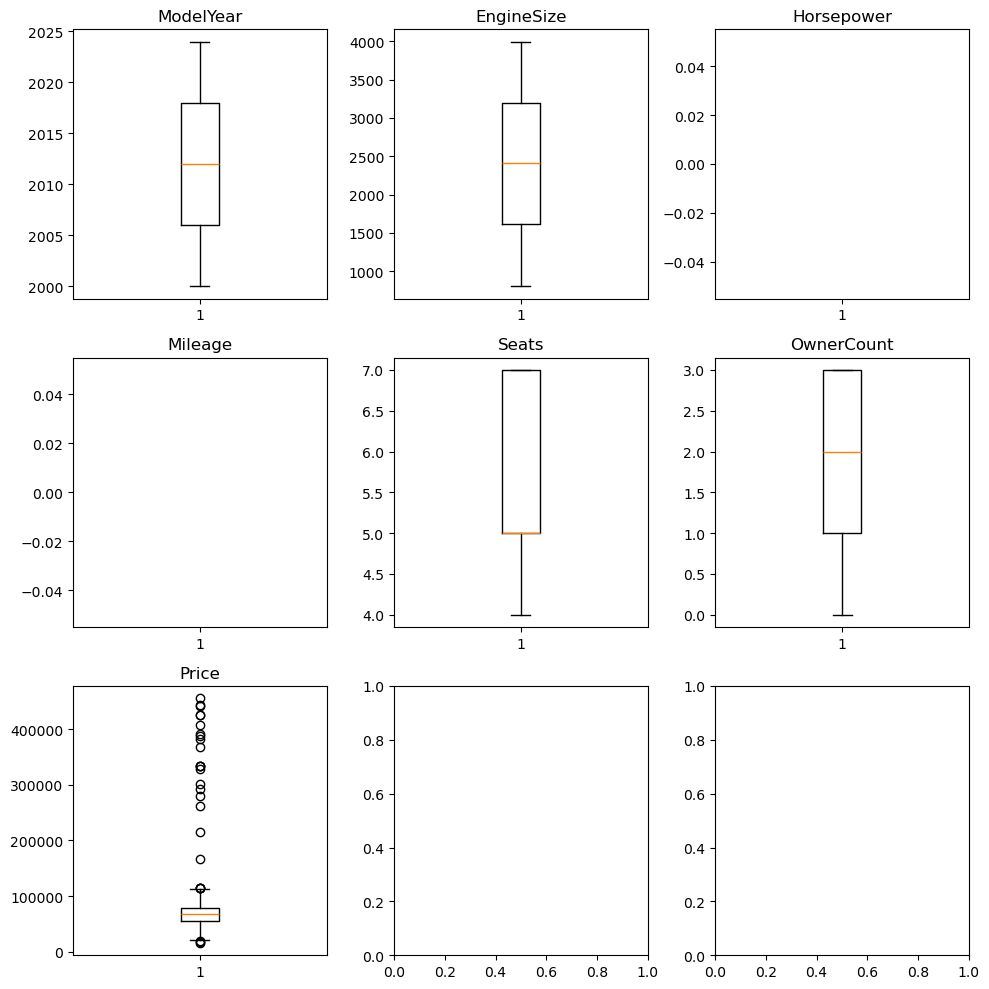

In [ ]:
cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Predict the price

- target column is price
- price is float, numeric, continuos data
- so it is a regression problem

- Data -> 10000 rows
- 700 rows I will gonna store for future

In [21]:
#  storing a sample for testing 

df_future = df.tail(700)
df_future.drop(columns="Price", inplace=True)

In [23]:
df = df.iloc[0:9300]

In [25]:
print(df.shape)
print(df_future.shape)

(9300, 10)
(700, 9)


## EDA and PreProcessing ->

- Null Values
- Duplicates
- Outliers
- Encoding

In [24]:
print(df.isnull().sum())

Brand             0
ModelYear         0
EngineSize        0
Horsepower      460
Mileage         457
FuelType        459
Transmission      0
Seats             0
OwnerCount        0
Price             0
dtype: int64


price we need coz that is our target col
